In [1]:
# Predittore di illiteracy BCI dalle run di baseline.
# Calcola, per ogni soggetto, quanto e' marcato il ritmo mu a riposo, e salva il risultato.
# Nessun modello viene addestrato: sono 61 secondi di segnale per soggetto.
# --- Preambolo standard ------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "dataset_description.json").exists()
)
DATA  = PROJECT_ROOT / "data"
PLOTS = PROJECT_ROOT / "src" / "plots"
sys.path.insert(0, str(PROJECT_ROOT / "src"))
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import mne
from util.smr_predictor import (
    subject_predictor, spectrum_for_plot,
    BASELINE_EYES_OPEN, BASELINE_EYES_CLOSED,
)

mne.set_log_level('ERROR')

root = DATA
n_subjects = 109
CHANNELS = ("C3", "C4")
RUN = BASELINE_EYES_OPEN     # occhi aperti: a occhi chiusi l'alfa occipitale sommerge il mu

rows = []
for i in range(1, n_subjects + 1):
    subject = f"{i:03d}"
    try:
        rows.append(subject_predictor(subject, root, run=RUN, channels=CHANNELS))
    except Exception as e:
        print(f"Soggetto {subject}: errore - {e}")

predictor = pd.DataFrame(rows).set_index("subject")

out_dir = PROJECT_ROOT / "src" / "results"
out_dir.mkdir(exist_ok=True)
predictor.to_csv(out_dir / "smr_predictor.csv")

print(f"Predittore calcolato su {len(predictor)} soggetti -> {out_dir / 'smr_predictor.csv'}")
print()
print(predictor[["C3_db", "C4_db", "mean_db", "min_db"]].describe().round(2))


Predittore calcolato su 109 soggetti -> c:\Users\papar\tesi-dataset\src\results\smr_predictor.csv

        C3_db   C4_db  mean_db  min_db
count  109.00  109.00   109.00  109.00
mean     2.97    3.09     3.03    2.26
std      4.03    3.88     3.76    3.32
min     -1.61   -1.29    -1.41   -1.61
25%      0.44    0.62     0.57    0.29
50%      1.15    1.64     1.42    0.93
75%      4.35    4.19     4.48    3.55
max     16.47   20.32    18.09   15.85


mu piu' marcato: soggetto 042 (18.1 dB)
mu piu' debole : soggetto 017 (-1.4 dB)


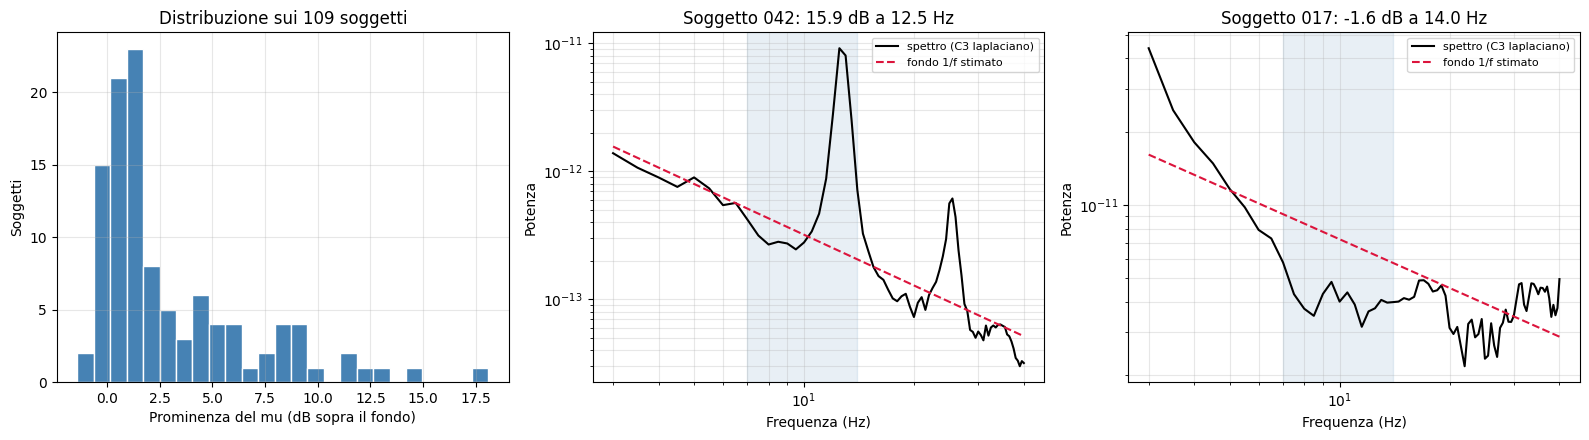

In [2]:
# Distribuzione del predittore e spettro di un soggetto forte contro uno debole.
import matplotlib.pyplot as plt

strongest = predictor["mean_db"].idxmax()
weakest = predictor["mean_db"].idxmin()
print(f"mu piu' marcato: soggetto {strongest} ({predictor.loc[strongest, 'mean_db']:.1f} dB)")
print(f"mu piu' debole : soggetto {weakest} ({predictor.loc[weakest, 'mean_db']:.1f} dB)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Distribuzione: quante persone hanno un ritmo mu utilizzabile
axes[0].hist(predictor["mean_db"], bins=25, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Prominenza del mu (dB sopra il fondo)")
axes[0].set_ylabel("Soggetti")
axes[0].set_title("Distribuzione sui 109 soggetti")
axes[0].grid(alpha=0.3)

# Gli spettri dei due estremi, con il fondo stimato sovrapposto
for ax, subject in zip(axes[1:], [strongest, weakest]):
    freqs, psd, background, measured = spectrum_for_plot(subject, root, channel="C3", run=RUN)
    ax.loglog(freqs, psd, color="black", lw=1.5, label="spettro (C3 laplaciano)")
    ax.loglog(freqs, background, color="crimson", ls="--", lw=1.5, label="fondo 1/f stimato")
    ax.axvspan(7, 14, alpha=0.12, color="steelblue")
    ax.set_xlabel("Frequenza (Hz)")
    ax.set_ylabel("Potenza")
    ax.set_title(f"Soggetto {subject}: {measured['prominence_db']:.1f} dB "
                 f"a {measured['peak_hz']:.1f} Hz")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(PLOTS / "smr_predictor.png", dpi=150)
plt.show()


Accuratezze trovate in RiemannFB_motor_imagery.ipynb: 10 soggetti
  media dei due emisferi    : rho = +0.721   p = 0.0186   n = 10
  minimo fra i due emisferi : rho = +0.770   p = 0.0092   n = 10

  soglia    esclusi   accuratezza media dei rimanenti
   0° perc.   0/10      66.82%
  10° perc.   1/10      68.12%
  20° perc.   2/10      70.90%
  30° perc.   3/10      72.65%
  40° perc.   4/10      71.96%


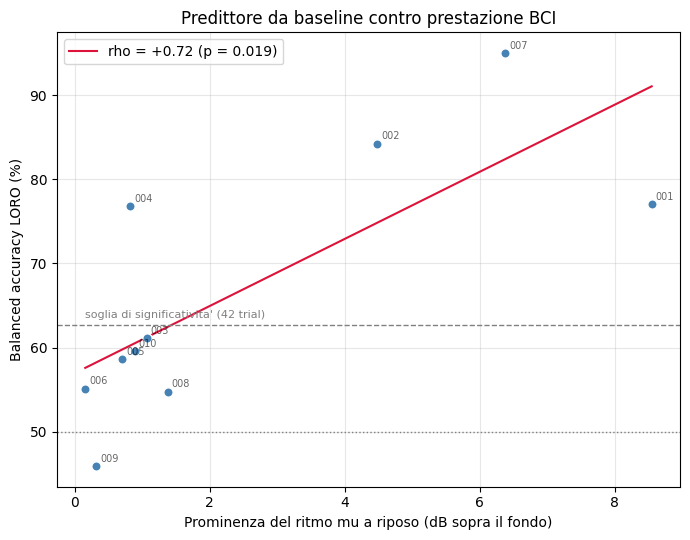

In [3]:
# Correlazione fra predittore e prestazione, e regola di screening.
# Le accuratezze vengono lette dall'output gia' salvato in una pipeline: cambia il nome del
# file per confrontare il predittore con un metodo diverso.
import re
import json as _json
from scipy.stats import spearmanr

PIPELINE = "RiemannFB_motor_imagery.ipynb"   # oppure FBCSP_motor_imagery.ipynb, CSP_...

nb_path = PROJECT_ROOT / "src" / "pipelines" / PIPELINE
nb = _json.loads(nb_path.read_text(encoding="utf-8"))
text = "".join("".join(o.get("text", []))
               for c in nb["cells"] for o in c.get("outputs", []))

performance = {s: float(a) for s, a in re.findall(r"Paziente (\d+): ([\d.]+)% con", text)}
print(f"Accuratezze trovate in {PIPELINE}: {len(performance)} soggetti")

common = [s for s in predictor.index if s in performance]
x = predictor.loc[common, "mean_db"].to_numpy()
x_min = predictor.loc[common, "min_db"].to_numpy()
y = np.array([performance[s] for s in common])

for label, values in [("media dei due emisferi", x), ("minimo fra i due emisferi", x_min)]:
    rho, p = spearmanr(values, y)
    print(f"  {label:26s}: rho = {rho:+.3f}   p = {p:.4f}   n = {len(y)}")

# --- Regola di screening -----------------------------------------------------
# Si scartano i soggetti sotto una soglia sul predittore e si guarda come cambia
# l'accuratezza media di quelli che restano.
print()
print("  soglia    esclusi   accuratezza media dei rimanenti")
for q in [0, 10, 20, 30, 40]:
    cut = np.percentile(x, q)
    kept = y[x >= cut]
    print(f"  {q:2d}° perc.  {len(y) - len(kept):2d}/{len(y)}      {kept.mean():.2f}%")

# --- Grafico ------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(x, y, s=45, color="steelblue", edgecolor="white", zorder=3)
for s, xi, yi in zip(common, x, y):
    ax.annotate(s, (xi, yi), fontsize=7, alpha=0.6,
                xytext=(3, 3), textcoords="offset points")

rho, p = spearmanr(x, y)
coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, np.polyval(coef, xs), color="crimson", lw=1.5,
        label=f"rho = {rho:+.2f} (p = {p:.3f})")

ax.axhline(50, color="gray", ls=":", lw=1)
ax.axhline(62.7, color="gray", ls="--", lw=1)
ax.text(x.min(), 63.5, "soglia di significativita' (42 trial)", fontsize=8, color="gray")

ax.set_xlabel("Prominenza del ritmo mu a riposo (dB sopra il fondo)")
ax.set_ylabel("Balanced accuracy LORO (%)")
ax.set_title("Predittore da baseline contro prestazione BCI")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS / "smr_vs_performance.png", dpi=150)
plt.show()
